In [1]:
import numpy as np
import pandas as pd

from numba import jit, prange, njit
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from pyscarcopula.src.Frank.FrankCopula  import ArchimedianCopula
from pyscarcopula.src.Gumbel.GumbelCopula  import GumbelCopula

from pyscarcopula.aux_functions.funcs import jit_pobs, pobs
import math
from scipy.optimize import minimize, Bounds

from typing import Literal


In [2]:
moex_data = pd.read_csv("data/moex_top.csv", index_col=0)
#tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK']
tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK', 'ROSN', 'KMAZ', 'AFKS', 'BSPB', 'MGNT']

moex_returns_pd = np.log(moex_data[tickers] / moex_data[tickers].shift(1))[1:601]
moex_returns = moex_returns_pd.values
pobs_data = pobs(moex_returns)


count_instruments = len(tickers)
copula = GumbelCopula(count_instruments)

In [3]:
@jit(nopython=True, parallel = True, cache = True)
def p_sampler_ou(alpha, dwt, init_state = None):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]

    T = len(dwt)
    dt = 1 / T
    xt = np.zeros(dwt.shape)
    #mu = -alpha1 / alpha2
    if init_state is None:
        xt[0] = mu
    else:
        xt[0] = init_state
    for k in range(1, T):
        A = -theta * (xt[k - 1] - mu)
        B = nu
        xt[k] = xt[k - 1] + A * dt + B * dwt[k]
    return xt

@jit(nopython = True, cache = True, parallel = True)
def get_avg_p_log_likelihood_ou(data, lambda_data, latent_process_tr, pdf, transform):
    avg_likelihood = 0
    copula_log_data = np.zeros(latent_process_tr)

    for k in prange(0, latent_process_tr):
        copula_log_data[k] = np.sum(np.log(np.maximum(pdf(data, transform(lambda_data[:,k])), 1e-100)))

    '''trick for calculation large values. calculate e^(sum(log_cop) - corr) instead of e^(sum(log_cop)).
    Do inverse correction at the end of calculations'''
    corr = max(copula_log_data)
    avg_likelihood = np.sum(np.exp(copula_log_data - corr)) / latent_process_tr
    return math.log(avg_likelihood) + corr


@jit(nopython = True, cache = True)
def p_jit_mlog_likelihood_ou(alpha: np.array, data: np.array, dwt: np.array, latent_process_tr: int,
                      print_path: bool, pdf: callable, transform: callable, init_state: np.array = None) -> float:
    
    '''initial data check'''
    if np.isnan(np.sum(alpha)) == True:
        res = 10000
        if print_path == True:
            print(alpha, 'incorrect params', res)
        return res
    
    lambda_data = p_sampler_ou(alpha, dwt, init_state)
    avg_log_likelihood = get_avg_p_log_likelihood_ou(data.T, lambda_data, latent_process_tr, pdf, transform)
    res = - avg_log_likelihood
    if np.isnan(res) == True:
        if print_path == True:
            print(alpha, 'unknown error', res)
    else:
        if print_path == True:
            print(alpha, res)
    return res


In [333]:
@jit(nopython=True, cache = True)
def moving_average(a, n = 3):
    ret = np.cumsum(a)
    ret[n:] = ret[n:] - ret[:-n]
    ret = ret[n - 1:] / n
    lin_arr1 = np.linspace(a[0], ret[0], n//2)
    index = len(a) - (len(lin_arr1) + len(ret))
    lin_arr2 = np.linspace(ret[-1], a[-1], index)
    ret = np.concatenate((lin_arr1, ret, lin_arr2 ))
    return ret

@jit(nopython=True, cache = True)
def linear_least_squares(matA: np.array, matB: np.array, alpha) -> np.array:
    '''Ridge regression
       Input  Ax = b
       Output x = (A.T * A + alpha * I) ^ (-1) * A.T * b
    '''
    I = np.identity(len(matA[0]))
    I[0][0] = 0
    return np.linalg.pinv( matA.T @ matA + alpha * I) @ matA.T @ matB 

@jit(nopython=True, cache = True)
def poly_fit(x, y, dim, fit_intercept = True, ridge_alpha = 0.0):
    '''least squares fit y = f(x), where f(x) - polynom with dimension = dim'''
    fi = int(fit_intercept)
    A = np.zeros((len(x), dim + fi))
    x_i = x
    for i in range(0, dim):
        #A[:,i + fi] = x**(i + 1)
        A[:,i + fi] = x_i
        x_i = x_i  * x
    if fit_intercept == True:
        A[:,0] = np.ones(len(x))
    res = linear_least_squares(A, y, ridge_alpha)
    return res

@jit(nopython=True, cache = True)
def poly(data, coef, intercept = True):
    '''returns polynom of data (c0 + c1 t + c2 t^2 + ...) with coeficients = coef. 
    If intercept == True: first coef considered as free parameter c0; Otherwise - as c1.'''
    dim = len(coef)
    res = np.zeros(len(data))
    fi = int(intercept)
    for i in range(0, dim):
        res += coef[i] * data**(1 - fi + i)
    return res



@jit(nopython=True, cache = True)
def bounded_polynom_fit(x, y, dim, type: Literal['two-sided', 'left-sided', 'right-sided', 'no bounds'], ridge_alpha = 0.0):
    if type == 'two-sided':
        x0 = x[0]
        x1 = x[-1]
        y0 = y[0]
        y1 = y[-1]
        c0 = (y0 * x1 - y1 * x0) / (x1 - x0)
        c1 = (y1 - y0) / (x1 - x0)
        d1 = -x0 - x1
        d2 = x0 * x1
        A = np.zeros((len(x), dim))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            A[:,i] = x_i * x * x + d1 * x_i * x + d2 * x
            x_i = x_i  * x
        A[:,0] += np.ones(len(x)) * c0
        A[:,1] += x * c1
        res = linear_least_squares(A, y, ridge_alpha)
        return res
    elif type == 'no bounds':
        fi = 1
        A = np.zeros((len(x), dim + fi))
        x_i = x
        for i in range(0, dim):
            A[:,i + fi] = x_i
            x_i = x_i  * x
        A[:,0] = np.ones(len(x))
        res = linear_least_squares(A, y, ridge_alpha)
        return res
    elif type == 'left-sided':
        x0 = x[0]
        y0 = y[0]
        A = np.zeros((len(x), dim))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            A[:,i] = x_i * (x - x0)
            x_i = x_i  * x
        res = linear_least_squares(A, y - y0, ridge_alpha)
        return res
    elif type == 'right-sided':
        x0 = x[-1]
        y0 = y[-1]
        A = np.zeros((len(x), dim))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            A[:,i] = x_i * (x - x0)
            x_i = x_i  * x
        res = linear_least_squares(A, y - y0, ridge_alpha)
        return res
    else:
        raise ValueError(f"type = {type} not implemented")


@jit(nopython=True, cache = True)
def bounded_polynom(x, y, coef, type: Literal['two-sided', 'left-sided', 'right-sided', 'no bounds']):
    if type == 'two-sided':
        dim = len(coef)
        x0 = x[0]
        x1 = x[-1]
        y0 = y[0]
        y1 = y[-1]
        c0 = (y0 * x1 - y1 * x0) / (x1 - x0)
        c1 = (y1 - y0) / (x1 - x0)
        d1 = -x0 - x1
        d2 = x0 * x1
        res = np.zeros(len(x))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            res += coef[i] * x_i
            x_i = x_i * x
        return (x * x + d1 * x + d2) * res + c1 * x + c0
    elif type == 'no bounds':
        dim = len(coef)
        res = np.zeros(len(x))
        fi = 1
        for i in range(0, dim):
            res += coef[i] * x**(1 - fi + i)
        return res
    elif type == 'left-sided':
        dim = len(coef)
        x0 = x[0]
        y0 = y[0]
        res = np.zeros(len(x))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            res += coef[i] * (x - x0) * x_i
            x_i = x_i * x
        return res + y0
    elif type == 'right-sided':
        dim = len(coef)
        x0 = x[-1]
        y0 = y[-1]
        res = np.zeros(len(x))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            res += coef[i] * x_i
            x_i = x_i * x
        return y0 + (x - x0) * res
    else:
        raise ValueError(f"type = {type} not implemented")


@jit(nopython=True, cache = True)
def mod_abs(x):
    b = 1
    #res = x * (2 / (1 + np.exp(-b * x)) - 1)
    res = x * np.tanh(b * x)
    return res

@jit(nopython=True, cache = True)
def poly_corr(t_data, coef, alpha, intercept):
    '''correct polynom fit result to be below a threshold that raises from norm constant'''
    res = poly(t_data, coef, intercept)
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * t_data)) + 0.0001
    #max_res = 1 / (2 * sigma2[-1]) - 0.5
    max_res = 1 / (2 * sigma2) - 0.0
    #max_res = 0.0
    exp_res = np.exp(-0.5*(max_res - res))
    return 1 / (1 + exp_res) * res
    #return -(mod_abs(max_res - res) - max_res - res) / 2


@jit(nopython=True, cache = True)
def correction(t_data, x_data, alpha):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]
    sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta * t_data)) + 0.0001
    max_res = 1 / (2 * sigma2) - 0.1
    exp_res = np.exp(-0.5*(max_res - x_data))
    return 1 / (1 + exp_res) * x_data
    #max_res = 0.0
    #return -(mod_abs(max_res - x_data) - max_res - x_data) / 2


def alpha_params(alpha):
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    mu = -alpha1 / alpha2
    theta = -alpha2
    nu = alpha3  
    D = nu**2/2
    print(f'alpha1 = {alpha1}, alpha2 = {alpha2}, alpha3 = {alpha3}')
    print(f'theta = {theta}, mu = {mu}, nu = {nu}, D = {D}')


In [5]:
@jit(nopython=True, cache = True)
def log_norm_ou(alpha: np.array, a1: np.array, a2: np.array, t: np.array, x0: np.array):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]
    # mu = -alpha1 / alpha2
    # theta = -alpha2
    # nu = alpha3
    D = nu**2/2
    sigma2 = D/theta * (1 - np.exp(-2 * theta * t))
    #xs = mu + x0 * np.exp(alpha2 * t)
    xs = (x0 - mu) * np.exp(-theta * t) + mu
    res = (a1**2 * sigma2 + 2 * a1 * xs + 2 * a2 * xs**2) / (2 - 4 * a2 * sigma2) - 0.5 * np.log(1 - 2*a2*sigma2)
    return res

@jit(nopython=True, cache = True)
def m_sampler_ou(alpha, a1t, a2t, dwt, init_state = None):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]

    T = len(dwt)
    dt = 1 / T
    xt = np.zeros(dwt.shape)
    # mu = -alpha1 / alpha2
    # theta = -alpha2
    # nu = alpha3
    D = nu**2 / 2
    if init_state is None:
        xt[0] = mu
    else:
        xt[0] = init_state
    for i in range(1, T):
        a1, a2 = a1t[i], a2t[i]
        a1dt, a2dt =  (a1t[i] - a1t[i - 1]) / dt, (a2t[i] - a2t[i - 1]) / dt
        #a1dt, a2dt = 0, 0
        t = i/T
        sigma2 = D / theta * (1 - np.exp(- 2 * theta * t))
        p = (1 - 2 * a2 * sigma2)
        sigma2w = sigma2 / p
        #xs = mu + xt[0] * np.exp(-theta * t)
        xs = (xt[0] - mu) * np.exp(-theta * t) + mu
        xsw = (xs + a1 * sigma2) / p
        sigma2dt = nu**2 - 2 * theta * sigma2
        sigma2wdt = (sigma2dt + 2 * sigma2**2 * a2dt) / p**2
        xsdt = -theta * (xs - mu)
        xswdt = (xsdt + a1 * sigma2dt + a1dt * sigma2) / p + 2 * xsw * (a2dt * sigma2 + a2 * sigma2dt) / p
        var = nu**2 / ( 1 - 2 * nu**2 * a2)
        B = nu #* np.sqrt( 1 - 2 * nu**2 * a2)
        A = xswdt - (xt[i - 1] - xsw) * (B**2 - sigma2wdt) / (2 * sigma2w)
        xt[i] = xt[i - 1] + A * dt + B * dwt[i]
    return xt

In [6]:
@jit(nopython=True, cache = True)
def ffit(x, y, dim, fit_intercept = True, ridge_alpha = 0.0):
    '''least squares fit y = f(x), where f(x) - polynom with dimension = dim'''
    fi = int(fit_intercept)
    A = np.zeros((len(x), 2 * dim + fi))
    for i in range(0, dim):
        n = 2 * i + fi
        #A[:,i + fi] = x**(i + 1)
        A[:,n] = np.sin(n * x)
        A[:,n + 1] = np.cos(n * x)
    if fit_intercept == True:
        A[:,0] = np.ones(len(x))
    res = linear_least_squares(A, y, ridge_alpha)
    return res


@jit(nopython=True, cache = True)
def ffdata(data, coef, intercept = True):
    '''returns polynom of data (c0 + c1 t + c2 t^2 + ...) with coeficients = coef. 
    If intercept == True: first coef considered as free parameter c0; Otherwise - as c1.'''
    dim = len(coef)
    res = np.zeros(len(data))
    fi = int(intercept)
    for i in range(0, (dim - fi)/2):
        n = 2 * i + fi
        res += coef[n] * np.sin(n * data)
        res += coef[n+1] * np.cos(n * data)
    res += coef[0]
    return res


In [714]:
#@jit(nopython=True, cache = True, parallel = True)
def m_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, m_iters, print_path, 
                             pdf, transform, init_state = None, fit_dim = 2, rigde_alpha = 0.0):
    T = len(data)
    norm_log_data = np.zeros((T, latent_process_tr))
    dt = 1/T
    t_data = np.linspace(0, 1, T)
    a_data = np.zeros((T, 3))
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]

    # mu = - alpha1 / alpha2
    # nu = alpha3
    # theta = -alpha2
    a1t = np.zeros(T)
    a2t = np.zeros(T)
    #res = np.zeros(m_iters)
    for j in range(0, m_iters):
        if j == 0:
            lambda_data = p_sampler_ou(alpha, dwt, init_state)
        else:
            lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)
            if np.isnan(np.sum(lambda_data)) == True:
                res = 10000
                if print_path == True:
                    print(alpha, 'm sampler nan', res)
                return res
        norm_log_data = np.zeros((T, latent_process_tr))
        a_mean = np.zeros(3)
        a_mean[0] = np.mean(a_data[:,0])
        a_mean[1] = np.mean(a_data[:,1])
        a_mean[2] = np.mean(a_data[:,2])
        a_data = np.zeros((T, 3))
        a_data[-1] = a_mean
        #for i in range(1, T):
        for i in range(T - 1, 0 , -1):
            copula_log_data = np.log(np.maximum(pdf(data[i], transform(lambda_data[i])), 1e-100))
            A = np.dstack( ( np.ones(latent_process_tr) , (lambda_data[i] - 0 * mu) , (lambda_data[i] - 0 * mu)**2 ) )[0]
            #A = np.dstack( ( np.ones(latent_process_tr) , (lambda_data[i] - 0 * mu) ) )[0]
            #b = copula_log_data + norm_log_data[i - 1]
            #if i == T - 1:
            norm_log_data[i] = log_norm_ou(alpha, a_data[i][1], a_data[i][2], dt, lambda_data[i - 1])
            b = copula_log_data + norm_log_data[i]
            sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta * (t_data[i])))
            xs = mu + (np.mean(lambda_data[i - 1]) - mu) * np.exp(-theta * t_data[i])
            #model = sm.OLS(b, A)
            #results = model.fit(cov_type='HC0')
            try:
                #r = 1/(j + 1)**2
                
                s2 = sigma2#nu**2/(2 * np.abs(theta))
                #r = 1/np.sqrt(2 * np.pi * s2 ) * np.exp(-xs**2/(2 * s2))
                r = 0.0
                #r = sigma2
                a_data[i - 1] = linear_least_squares(A, b, r) #1/1000 * (a_data[i][1] - a_data[i][2])**2 / (1 + a_data[i][1]**2 + a_data[i][2]**2)
                #a_data[i - 1] = results.params
                #print(i, j, results.rsquared, a_data[i - 1])

                #a_data[i - 1][1] = np.minimum(a_data[i - 1][1], 0.0)
                a_data[i - 1][2] = np.minimum(a_data[i - 1][2], 1/(2 * sigma2))
                #a_data[i - 1][2] = np.minimum(a_data[i - 1][2], 0.0) #1/(2 * sigma2)
                

                # Fit the model with heteroskedasticity-robust standard errors (HC3)
                
                
                # if i != T - 1:
                #     a_data[i - 1][1] = np.minimum(2 * np.abs(a_data[i - 1][1]), np.abs(a_data[i][1])) * np.sign(a_data[i][1])
                a_data[i - 1] = np.maximum(np.minimum(a_data[i - 1], 3000),-3000)
            except:
                res = 10000
                if print_path == True:
                    print(alpha, 'ls problem fail', res, i)
                return res
            #norm_log_data[i] = log_norm_ou(alpha, a_data[i][1], a_data[i][2], dt, lambda_data[i - 1])
            #norm_log_data[i - 1] = log_norm_ou(alpha, a_data[i - 1][1], a_data[i - 1][2], dt, lambda_data[i - 1])
        a_data_a1 = a_data[:,1].copy()
        a_data_a2 = a_data[:,2].copy()
        val = np.minimum(np.mean(a_data_a2), 0)
        if a_data_a2[-1] > val:
            a_data_a2[-1] = val

        intercept = True
        
        # a1_params = poly_fit(t_data, a_data_a1, dim = j, fit_intercept = intercept)
        # a2_params = poly_fit(t_data, a_data_a2, dim = j, fit_intercept = intercept)
        # a1t = poly(t_data, a1_params, intercept = intercept)
        # a2t = poly_corr(t_data, a2_params, alpha, intercept = intercept)
        #a2t = poly(t_data, a2_params, intercept = False)

        fit_type1 = 'no bounds'
        fit_type2 = 'right-sided'
        dim = j + 1
        #dim = 2
        a1_params = bounded_polynom_fit(t_data, a_data_a1, dim = dim, ridge_alpha = 0.0, type = fit_type1)
        a2_params = bounded_polynom_fit(t_data, a_data_a2, dim = dim, ridge_alpha = 0.0, type = fit_type2)

        a1t = bounded_polynom(t_data, a_data_a1, a1_params, type = fit_type1)
        a2t = bounded_polynom(t_data, a_data_a2, a2_params, type = fit_type2)
        a2t = correction(t_data, a2t, alpha)

        # a1_params = ffit(t_data, a_data_a1, dim = fit_dim, ridge_alpha = 1.0)
        # a2_params = ffit(t_data, a_data_a2, dim = fit_dim, ridge_alpha = 1.0)

        # a1t = ffdata(t_data, a1_params)
        # a2t = ffdata(t_data, a2_params)
        # a2t = correction(t_data, a2t, alpha)
    # a1t = 0 * a1t
    # a2t = 0 * a2t

    log_likelihood = np.zeros(latent_process_tr)
    lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)
    for i in range(T - 1, 0, -1):
        a1, a2 = a1t[i], a2t[i]
        norm_log_data[i] = log_norm_ou(alpha, a1, a2, dt, lambda_data[i - 1])
    norm_log_data[0] = log_norm_ou(alpha, a1t[0], a2t[0], dt, lambda_data[0])

    for k in range(0, latent_process_tr):
        copula_log_data = np.log(np.maximum(pdf(data.T, transform(lambda_data[:,k]) ), 1e-100))
        g = (a1t * (lambda_data[:,k] - 0 * mu)  + a2t * (lambda_data[:,k] - 0 * mu)**2)
        log_likelihood[k] = np.sum(copula_log_data + norm_log_data[:,k] - g)
    xc = np.max(log_likelihood)
    avg_likelihood = np.sum(np.exp(log_likelihood - xc)) / latent_process_tr
    res = np.log(avg_likelihood) + xc
    res = -res
    # if (j > 0 and res[j - 1] < 0 and res[j] > 0) or np.isnan(res[j]) == True:
    #     res[-1] = p_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, False, pdf, transform, init_state)
    #     if print_path == True:
    #         print(res)
    #         print(alpha, 'instability encountered. return to p sampler', res[-1])
    #     return a_data
    #     return res[-1]
    if print_path == True:
        print(alpha, res)
    #print(r)
    return a_data


In [686]:
i = 7
data = pobs_data[0 + i:250 + i]
T = len(data)
latent_process_tr = 500

In [687]:
T = len(data)
#s = np.random.randint(0, 100000)
s = 10
rng = np.random.RandomState(seed=s)
dwt = rng.normal(0, 1, size = (len(pobs_data), latent_process_tr)) * np.sqrt(1/T)
dwt = dwt[i:len(data) + i]

In [35]:
#bounds = Bounds([-700., -700, 0.0], [700, 700, 700])
latent_process_tr = 500
data = pobs_data[0:250]

alpha = np.array([20.40351061, 0.49428505, 0.47159938])


constr = {'type': 'ineq', 'fun': lambda x: np.abs(x[1]) - x[2]**2 - 0.001}

log_min = minimize(m_jit_mlog_likelihood_ou, alpha,
                            args=(data, dwt, latent_process_tr, 5, True, copula.np_pdf(), copula.transform, init_state),
                            method='SLSQP',
                            #bounds = bounds,
                            #constraints = constr,
                            options={'ftol': 1e-4} )
log_min

[20.40351061  0.49428505  0.47159938] -256.33941117600847
[20.40351062  0.49428505  0.47159938] -256.3394111736146
[20.40351061  0.49428506  0.47159938] -256.3394125538251
[20.40351061  0.49428505  0.47159939] -256.3394112223649
[20.24286226 92.95799583  3.58252696] m sampler nan 10000
[20.366971   21.52523897  1.17918265] m sampler nan 10000
[20.39985665  2.59738044  0.54235771] 2120.334833739833
[20.40314521  0.70459459  0.47867521] -248.70921996808454
[20.40337936  0.56983087  0.47414111] -259.8954325373402
[20.40337937  0.56983087  0.47414111] -259.89543253680847
[20.40337936  0.56983089  0.47414111] -259.8954325506152
[20.40337936  0.56983087  0.47414112] -259.89543248367494
[20.36849204  0.83817131 -3.17866809] -229.95446598937446
[20.39798742  0.61130367 -0.09041121] -251.88955013870506
[20.40282542  0.57409151  0.41614274] -259.97925410121064
[20.40282544  0.57409151  0.41614274] -259.9792541005958
[20.40282542  0.57409153  0.41614274] -259.97925399968295
[20.40282542  0.574091

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -260.03146634499393
       x: [ 1.854e+01  5.708e-01  4.224e-01]
     nit: 9
     jac: [ 3.433e-04 -3.883e-02 -5.711e-03]
    nfev: 42
    njev: 9

In [691]:
states = np.array([
[331.33385919,  -0.58093971,   3.54181363],
[331.3338655 ,  -0.57671378,   3.53955888],
[331.3338655 ,  -0.57671378,   3.53955888],
[341.12273973 , -0.57750706,   3.44087051],
[341.12274711 , -0.57828366,   3.44155765],
[341.12275333 , -0.57797441,   3.44168638],
[330.90183529 , -0.57360178,   4.21631111]    
])

In [9]:
from pyscarcopula.sampler.sampler_ou import p_sampler_one_step_ou

In [692]:
s = 10
rng = np.random.RandomState(seed= s)
dwt = rng.normal(0, 1, size = (len(pobs_data), latent_process_tr)) * np.sqrt(1/T)

In [693]:
init_state = np.zeros(latent_process_tr)
for k in range(1, len(states)):
    init_state = p_sampler_one_step_ou(states[k], dwt[k - 1], 1/T, init_state)

In [726]:
#%%timeit
s = np.random.randint(0, 1000000)
s = 10 #715606
#s = 715606
rng = np.random.RandomState(seed= s)
dwt = rng.normal(0, 1, size = (len(pobs_data), latent_process_tr)) * np.sqrt(1/T)
i = 104
dwt = dwt[i:len(data) + i]

#alpha = np.array([-0.56395007,  2.59290612, -1.41567972])
#alpha = np.array([4.51551114, -0.41554241, -0.29707367])
#alpha = np.array([0.74446907,  0.69987999, -0.04472599])
#alpha = np.array([0.56390725, -0.61465765,  0.42402798])
alpha = np.array([383.93433356,   0.64414548,   3.75406398])
init_state = None
p_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, True, copula.np_pdf(), copula.transform, init_state= init_state)


a_data = m_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, 15, True, 
                                  copula.np_pdf(), copula.transform, init_state=init_state)

[383.93433356   0.64414548   3.75406398] -179.79711038923105
[383.93433356   0.64414548   3.75406398] m sampler nan 10000


In [611]:
lp = 100000
dwt = np.random.normal(0, 1, size = (T, lp)) * np.sqrt(1/T)
p_jit_mlog_likelihood_ou(alpha, data, dwt, lp, True, copula.np_pdf(), copula.transform)


[ 0.74446907  0.69987999 -0.04472599] -234.02254585663502


-234.02254585663502

In [ ]:
bounds = Bounds([-10, -10, -10], [10, 10, 10])
latent_process_tr = 500
T = len(data)
s = np.random.randint(0, 100000)
s = 95764
rng = np.random.RandomState(seed=s)
dwt = rng.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)

log_min = minimize(m_jit_mlog_likelihood_ou, alpha,
                            args=(data, dwt, latent_process_tr, 5, True, copula.np_pdf(), copula.transform),
                            method='SLSQP',
                            bounds = bounds,
                            options={'ftol': 1e-3} )
log_min

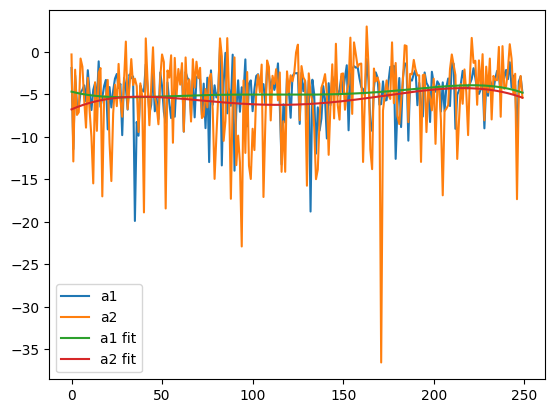

In [709]:
deg = 5

t_data = np.linspace(0, 1, T)
a_data_a1 = a_data[:,1].copy()
a_data_a2 = a_data[:,2].copy()

val = np.minimum(np.mean(a_data_a2), 0)
if a_data_a2[-1] > val:
    a_data_a2[-1] = val

intercept = True

# a1_params = poly_fit(t_data, a_data_a1, dim = deg, fit_intercept = intercept, ridge_alpha = 0.0)
# a2_params = poly_fit(t_data, a_data_a2, dim = deg, fit_intercept = intercept, ridge_alpha = 0.0)
# a1t = poly(t_data, a1_params, intercept = intercept)
# a2t = poly_corr(t_data, a2_params, alpha, intercept = intercept)
#a2t = poly(t_data, a2_params, intercept = intercept)

# alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
# sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * (t_data)))
# plt.plot(sigma2, label = 'max a2')

#
fit_type = 'right-sided'

# a_data_a1[-1] = np.mean(a_data_a1)
# a_data_a2[-1] = np.mean(a_data_a2)
#a_data_a2[240:] = np.mean(a_data_a2)

a1_params = bounded_polynom_fit(t_data, a_data_a1, dim = deg, ridge_alpha = 0.0, type = fit_type)
a2_params = bounded_polynom_fit(t_data, a_data_a2, dim = deg, ridge_alpha = 0.0, type = fit_type)

a1t = bounded_polynom(t_data, a_data_a1, a1_params, type = fit_type)
a2t = bounded_polynom(t_data, a_data_a2, a2_params, type = fit_type)

a2t = correction(t_data, a2t, alpha)


#plt.plot(-a2t * np.tanh(1 * a2t), label = 'a2 test')


plt.plot(a_data[:,1], label = 'a1')
plt.plot(a_data[:,2], label = 'a2')

plt.plot(a1t, label = 'a1 fit')
plt.plot(a2t, label = 'a2 fit')
#plt.plot(fitted, label = 'a2 fit test')
#plt.plot(y_fit, label='Fit')

#plt.plot(a2t_old, label = 'a2 fit old')
# a1_params = ffit(t_data, a_data_a1, dim = 4, ridge_alpha = 0.0)
# a1t = ffdata(t_data, a1_params)

#plt.plot(par2, label = '?')
#plt.plot(moving_average(a_data[:,1],60), label = 'a1 ma fit')
plt.legend()

In [464]:
a2_params

array([  -21.16661773,   912.40901622, -4350.48257939,  8612.72557367, -5151.21547549])

In [475]:
x = t_data
y = a_data_a2
dim = 5
x0 = x[-1]
y0 = y[-1]
A = np.zeros((len(x), dim))
x_i = np.ones(len(x))
for i in range(0, dim):
    #A[:,i] = x_i * (x - x0) + y0
    A[:,i] = x**i * (x - x0)
    #x_i = x_i  * x
#A[:,0] += np.ones(len(x)) * y0

In [477]:
A = np.vstack([np.ones(len(x))* (x - x0), x* (x - x0), x**2* (x - x0), x**3* (x - x0), x**4* (x - x0)]).T


In [479]:
coeffs, _, _, _ = np.linalg.lstsq(A, y - y0, rcond=None)
coeffs

array([   -8.9242464 ,   693.76551864, -2798.94963885,  5119.49030239, -2688.24635193])

In [452]:
A

array([[-5.36027765e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [-5.35626158e+00, -3.99993548e-03, -1.60639979e-05, -6.45140479e-08, -2.59092562e-10],
       [-5.35224552e+00, -7.96761343e-03, -6.39968950e-05, -5.14031285e-07, -4.12876534e-09],
       ...,
       [-4.36830977e+00, -7.96761343e-03, -7.90361653e-03, -7.84013367e-03, -7.77716071e-03],
       [-4.36429371e+00, -3.99993548e-03, -3.98387149e-03, -3.96787200e-03, -3.95193677e-03],
       [-4.36027765e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [461]:
import numpy as np
from scipy.optimize import curve_fit

# Define the objective function
y0 = a_data_a2[-1]
x0 = t_data[-1]
def objective(x, c0, c1, c2, c3, c4):
    return y0 + (x - x0) * (c0 + c1 * x + c2 * x**2 + c3 * x**3 + c4 * x**4)

# Generate some dummy data

# Initial guesses for a, b, c, d
initial_guess = [1.0, 1.0, 1.0, 1.0]

# Perform curve fitting
popt, pcov = curve_fit(objective, t_data, a_data_a2)#, p0=initial_guess)

# Print the optimized parameters
print("Optimized Parameters:", popt)

Optimized Parameters: [   -8.92424158   693.76543764 -2798.94926648  5119.48967528 -2688.24600526]


In [420]:
fitted = objective(t_data, *popt)

In [482]:

@jit(nopython=True, cache = True)
def bounded_polynom_fit(x, y, dim, type: Literal['two-sided', 'left-sided', 'right-sided', 'no bounds'], ridge_alpha = 0.0):
    if type == 'two-sided':
        x0 = x[0]
        x1 = x[-1]
        y0 = y[0]
        y1 = y[-1]
        c0 = (y0 * x1 - y1 * x0) / (x1 - x0)
        c1 = (y1 - y0) / (x1 - x0)
        d1 = -x0 - x1
        d2 = x0 * x1
        A = np.zeros((len(x), dim))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            A[:,i] = x_i * x * x + d1 * x_i * x + d2 * x
            x_i = x_i  * x
        A[:,0] += np.ones(len(x)) * c0
        A[:,1] += x * c1
        res = linear_least_squares(A, y, ridge_alpha)
        return res
    elif type == 'no bounds':
        fi = 1
        A = np.zeros((len(x), dim + fi))
        x_i = x
        for i in range(0, dim):
            A[:,i + fi] = x_i
            x_i = x_i  * x
        A[:,0] = np.ones(len(x))
        res = linear_least_squares(A, y, ridge_alpha)
        return res
    elif type == 'left-sided':
        x0 = x[0]
        y0 = y[0]
        A = np.zeros((len(x), dim))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            A[:,i] = x_i * (x - x0)
            x_i = x_i  * x
        res = linear_least_squares(A, y - y0, ridge_alpha)
        return res
    elif type == 'right-sided':
        x0 = x[-1]
        y0 = y[-1]
        A = np.zeros((len(x), dim))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            A[:,i] = x_i * (x - x0)
            x_i = x_i  * x
        res = linear_least_squares(A, y - y0, ridge_alpha)
        return res
    else:
        raise ValueError(f"type = {type} not implemented")


@jit(nopython=True, cache = True)
def bounded_polynom(x, y, coef, type: Literal['two-sided', 'left-sided', 'right-sided', 'no bounds']):
    if type == 'two-sided':
        dim = len(coef)
        x0 = x[0]
        x1 = x[-1]
        y0 = y[0]
        y1 = y[-1]
        c0 = (y0 * x1 - y1 * x0) / (x1 - x0)
        c1 = (y1 - y0) / (x1 - x0)
        d1 = -x0 - x1
        d2 = x0 * x1
        res = np.zeros(len(x))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            res += coef[i] * x_i
            x_i = x_i * x
        return (x * x + d1 * x + d2) * res + c1 * x + c0
    elif type == 'no bounds':
        dim = len(coef)
        res = np.zeros(len(x))
        fi = 1
        for i in range(0, dim):
            res += coef[i] * x**(1 - fi + i)
        return res
    elif type == 'left-sided':
        dim = len(coef)
        x0 = x[0]
        y0 = y[0]
        res = np.zeros(len(x))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            res += coef[i] * (x - x0) * x_i
            x_i = x_i * x
        return res + y0
    elif type == 'right-sided':
        dim = len(coef)
        x0 = x[-1]
        y0 = y[-1]
        res = np.zeros(len(x))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            res += coef[i] * x_i
            x_i = x_i * x
        return y0 + (x - x0) * res
    else:
        raise ValueError(f"type = {type} not implemented")



Coefficients: [-6.34527274e-02 -5.34679699e+02  2.13239471e+03 -3.81296301e+03
  2.65737548e+03 -4.16613621e+02]


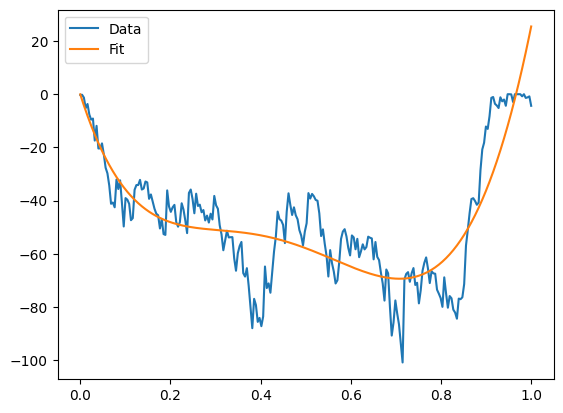

In [426]:
import numpy as np

def poly_fit(x, y, degree):
    """
    Fit a polynomial of degree 'degree' to the data (x, y)
    """
    A = np.vstack([x**i for i in range(degree+1)]).T
    coeffs, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    return coeffs

def poly_eval(x, coeffs):
    """
    Evaluate the polynomial with coefficients 'coeffs' at points 'x'
    """
    return np.sum([coeffs[i] * x**i for i in range(len(coeffs))], axis=0)

# Example usage
x = t_data
y = a_data_a2

degree = 5  # Fit a quadratic polynomial
coeffs = poly_fit(x, y, degree)

print("Coefficients:", coeffs)

x_fit = t_data#np.linspace(1, 5, 100)
y_fit = poly_eval(x_fit, coeffs)

import matplotlib.pyplot as plt
plt.plot(x, y, label='Data')
plt.plot(x_fit, y_fit, '-', label='Fit')
plt.legend()
plt.show()

In [352]:
@jit(nopython=True, cache = True)
def mod_abs(x):
    b = 1
    #res = x * (2 / (1 + np.exp(-b * x)) - 1)
    res = x * np.tanh(b * x)
    return res

@jit(nopython=True, cache = True)
def correction(t_data, x_data, alpha):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]
    sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta * t_data)) + 0.0001
    max_res = 1 / (2 * sigma2) - 0.1
    #exp_res = np.exp(-50*(max_res - x_data))
    #return 1 / (1 + exp_res) * x_data
    #max_res = 0.0
    return -(mod_abs(max_res - x_data) - max_res - x_data) / 2

In [437]:
dwt = np.random.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)

log_likelihood = np.zeros(latent_process_tr)
norm_log_data = np.zeros((T, latent_process_tr))

alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
mu = -alpha1 / alpha2

#a1t = 1 + t_data #14 * np.sin(8 * np.pi/2 * t_data)
#a2t = 0 *  t_data #-12 * np.cos(4 * np.pi/2 * t_data)**2
#a1t = 5 * t_data #* 0
#a2t = -30 * t_data # * 0

lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt)
dt = 1/T
for i in range(1, T):
    a1, a2 = a1t[i], a2t[i]
    #norm_log_data[i] = log_norm_ou_test(lambda_data[i], i/T, alpha, mu, a1, a2)
    norm_log_data[i] = log_norm_ou(alpha, a1, a2, 1/T, lambda_data[i - 1])
    #norm_log_data[i] = log_norm_ou(alpha, a1, a2, i/T, mu)

for k in range(0, latent_process_tr):
    copula_log_data = np.log(np.maximum(copula.np_pdf()(data.T, copula.transform(lambda_data[:,k])), 1e-100))
    g = (a1t * (lambda_data[:,k] - 0 * mu)  + a2t * (lambda_data[:,k] - 0 * mu)**2)
    log_likelihood[k] = np.sum(copula_log_data + norm_log_data[:,k] - g)
xc = np.max(log_likelihood)
avg_likelihood = np.sum(np.exp(log_likelihood - xc)) / latent_process_tr
res = np.log(avg_likelihood) + xc
print(-res)
p_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, False, copula.np_pdf(), copula.transform)


-217.23693108354618


-179.89414233545813

In [748]:
def log_pdf_p(x, t, alpha, x0):
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    mu = -alpha1 / alpha2
    theta = -alpha2
    nu = alpha3
    D = nu**2/2
    if t == 0:
        t = t + 0.01
    sigma2 = D / theta * (1 - np.exp(- 2 * theta * t))
    xs = (x0 - mu) * np.exp(-theta * t) + mu
    return  -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

In [787]:
#lambda_data = np.random.uniform(-2, 2, size=(T + 1, 100000))
dwt = np.random.normal(0, 1, size=(T + 1, 10000)) * np.sqrt(1/T) 
lambda_data = p_sampler_ou(alpha, dwt)

for k in range(0, latent_process_tr):
    copula_log_data = np.log(copula.np_pdf()(pobs_data.T, copula.transform(lambda_data[:,k][1:])))
    #g = log_pdf_p(lambda_data[:,k][1:], 1/T, alpha, lambda_data[:,k][0:T])
    g = 0
    log_likelihood[k] = np.sum(copula_log_data + g)
xc = np.max(log_likelihood)
avg_likelihood = np.sum(np.exp(log_likelihood - xc)) / latent_process_tr
res = np.log(avg_likelihood) + xc
print(-res)

-370.4775664360208


In [ ]:
lp = [100, 200, 500, 1000, 5000, 10000]
alpha = np.array([-0.19788412463810046, 0.6706628689464917, -0.7031497915906386])

print(alpha)
for lp_i in lp:
    res_p_i = []
    for k in range(0, 50):
        dwt = np.random.normal(0, 1, size = (T, lp_i)) * np.sqrt(1/T)
        res = p_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, lp_i, False, copula.np_pdf(), copula.transform)
        res_p_i.append(res)
    print(lp_i, np.mean(res_p_i), np.std(res_p_i) )

In [ ]:
lp = [100, 200, 500, 1000, 5000, 10000]
alpha = np.array([-0.19788412463810046, 0.6706628689464917, -0.7031497915906386])

print(alpha)
for lp_i in lp:
    res_p_i = []
    for k in range(0, 50):
        dwt = np.random.normal(0, 1, size = (T, lp_i)) * np.sqrt(1/T)
        res = m_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, lp_i, 5, False, copula.np_pdf(), copula.transform)
        if np.isnan(res):
            break
        res_p_i.append(res)
    break
    print(lp_i, np.mean(res_p_i), np.std(res_p_i) )

In [720]:
#dwt = np.random.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)
# a1t = np.sin(8 * np.pi/2 * t_data)
# a2t = np.zeros(T)
p = p_sampler_ou(alpha, dwt)
m = m_sampler_ou(alpha, a1t, a2t, dwt)

In [364]:
a2t[200:]= a2t[200]

In [722]:
dt = 1/T
a1dt = []
a2dt = []
for i in range(1, T):
    a1dti, a2dti =  (a1t[i] - a1t[i - 1]) / dt, (a2t[i] - a2t[i - 1]) / dt
    a1dt.append(a1dti)
    a2dt.append(a2dti)

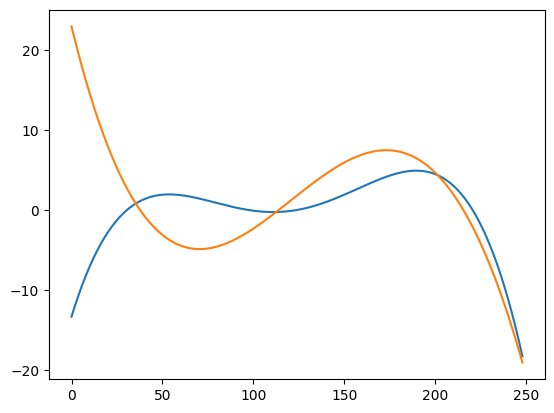

In [723]:
plt.plot(a1dt)
plt.plot(a2dt)

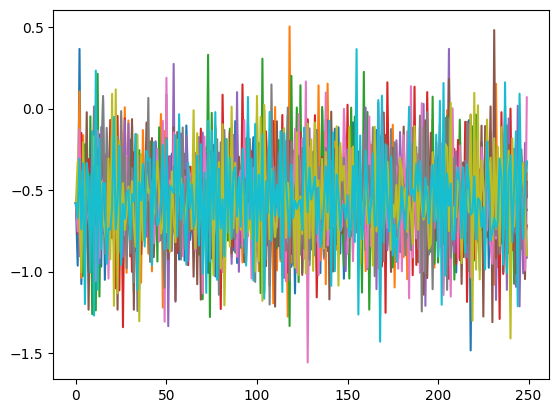

In [724]:
for i in range(0, 10):
    t = np.random.randint(0, latent_process_tr)
    plt.plot(m[:,t], label = f'm {t}')
    #plt.plot(p[:,t], label = f'p {t}')

In [132]:
theta, mu, nu = alpha[0], alpha[1], alpha[2]
D = nu**2 / 2
At = []
Bt = []
mod_a1t = a2t * np.exp(-0.0000005 * a2t**2)
mod_a2t = a2t * np.exp(-0.0000005 * a2t**2)

for i in range(1, T):
    a1, a2 = mod_a1t[i], mod_a2t[i]
    a1dt, a2dt =  (mod_a1t[i] - mod_a1t[i - 1]) / dt, (mod_a2t[i] - mod_a2t[i - 1]) / dt
    t = i/T
    sigma2 = D / theta * (1 - np.exp(- 2 * theta * t))
    p = (1 - 2 * a2 * sigma2)
    sigma2w = sigma2 / p

    x0 = mu
    xs = (x0 - mu) * np.exp(-theta * t) + mu
    xsw = (xs + a1 * sigma2) / p
    sigma2dt = nu**2 - 2 * theta * sigma2
    sigma2wdt = (sigma2dt + 2 * sigma2**2 * a2dt) / p**2
    xsdt = -theta * (xs - mu)
    xswdt = (xsdt + a1 * sigma2dt + a1dt * sigma2) / p + 2 * xsw * (a2dt * sigma2 + a2 * sigma2dt) / p
    var = nu**2 / ( 1 - 2 * nu**2 * a2)
    B = nu 
    A = xswdt - (x0 - xsw) * (B**2 - sigma2wdt) / (2 * sigma2w)
    At.append(A)
    Bt.append(B)

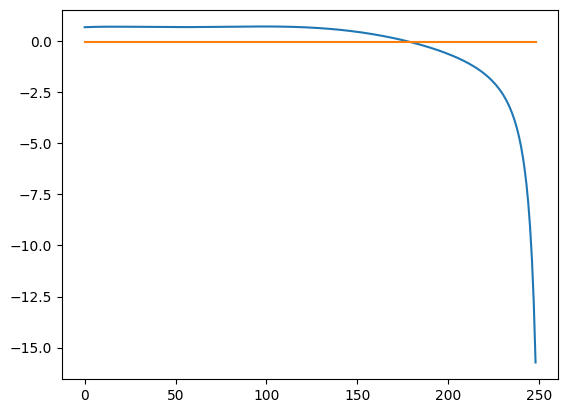

In [133]:
plt.plot(At)
plt.plot(Bt)

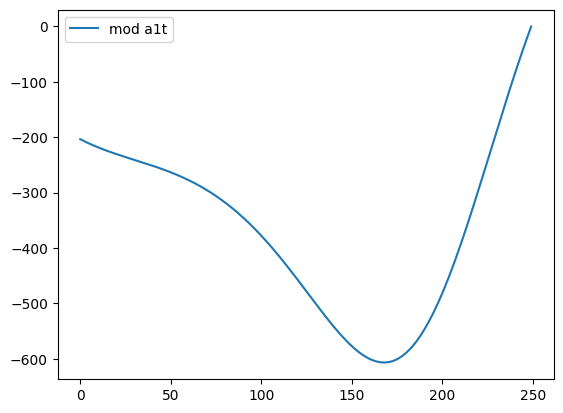

In [131]:
#plt.plot(a1t, label = 'a1t')
plt.plot(a1t * np.exp(-0.0000005 * a1t**2), label = 'mod a1t')

#plt.plot(a2t, label = 'a2t')
#plt.plot(-np.abs(a2t)**(1/2), label = 'mod a1t')

plt.legend()